In [7]:
import numpy as np
import nilearn.plotting as nplt
import nibabel as nib
import matplotlib.pyplot as plt
import os.path as op
from  nilearn.datasets import fetch_surf_fsaverage
from os import listdir
import seaborn as sns   
import pandas as pd
from utils_02 import get_GMmargulies_cmap
fsaverage = fetch_surf_fsaverage()

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
grad_folder = 'derivatives/gradients'
plot_folder_name = '/Users/mrenke/data/ds-stressrisk/plots_and_ims/gradients123_reordMaskFlip'
subList = [f[4:6] for f in listdir(op.join(bids_folder, grad_folder)) if f[0:4] == 'sub-' and len(f)==6]

specification = '_reordMaskFlip'
cmap = get_GMmargulies_cmap()

In [2]:
gradInsp_subList = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/gradient_inspection_list.csv')

cleanGM_subList = gradInsp_subList[gradInsp_subList['Order'] == '1']['Subject'].to_list()
cleanGM_subList = [int(x) for x in cleanGM_subList]
cleanGM_subList = ["{:02d}".format(x) for x in cleanGM_subList]

In [30]:
# behavioral data
behavSummary_path ='/Users/mrenke/data/ds-stressrisk/interim_sum_data/'
file = 'subjectwise_gamma.tsv'#'subwise_seswise_n1_evidence_sd.csv' # gamma - only ses 1, all subjects
df_behav = pd.read_csv(op.join(behavSummary_path, file), sep='\t')
df_behav.head()

,subject,gamma
0,1,2.978560
1,2,2.707927
2,3,1.818231
3,4,2.106312
4,5,2.737986


In [12]:
df_behav[df_behav['gamma'] == df_behav.loc[52,'gamma'] ]

,subject,gamma
52,130,1.934267


In [6]:
from utils import npFileTofs5Gii

sub = 'average_cmunfil_01'
specification = '_noParcel_aligned-marg'
npFileTofs5Gii(sub,1, specification=specification,bids_folder=bids_folder)

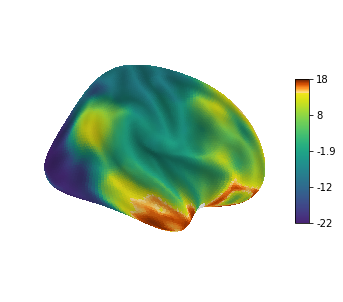

In [15]:
hemi = 'R'
grad_n = 1
file = f'sub-average_cmunfil_01_ses-1_task-risk_space-fsaverage5_hemi-{hemi}_grad{grad_n}_noParcel_aligned-marg.surf.gii'
ref_g1_hR = nib.load(op.join(bids_folder, grad_folder, f'sub-average_cmunfil_01/ses-1/{file}')).agg_data()

fsaverage = fetch_surf_fsaverage()

nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= ref_g1_hR, # infl_right # pial_right
               view= 'medial',cmap=cmap, colorbar=True,
               bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.5,
               )
plt.show()

In [50]:
space = 'fsaverage5'

hemi = 'R'
grad_n = 1
file = f'sub-average_cmunfil_01_ses-1_task-risk_space-fsaverage5_hemi-{hemi}_grad{grad_n}_noParcel_aligned-marg.surf.gii'
ref_g1_hR = nib.load(op.join(bids_folder, grad_folder, f'sub-average_cmunfil_01/ses-1/{file}')).agg_data()

df_comb = pd.DataFrame()
for sub in cleanGM_subList:
    gm1 = nib.load(op.join(bids_folder,grad_folder,f'sub-{sub}','ses-1',f'sub-{sub}_ses-1_task-risk_space-{space}_hemi-{hemi}_grad{grad_n}{specification}.surf.gii')).agg_data()
    nonNan_ind = ~np.isnan(gm1)
    cor = np.corrcoef(ref_g1_hR[nonNan_ind], gm1[nonNan_ind])
    df = pd.DataFrame(data={'subject':int(sub), 'cor':cor[(0,1)]}, index=[0])
    df_comb = pd.concat([df_comb, df],axis=0)   


In [51]:
df_comb = df_comb.join(df_behav.set_index('subject'), on='subject')

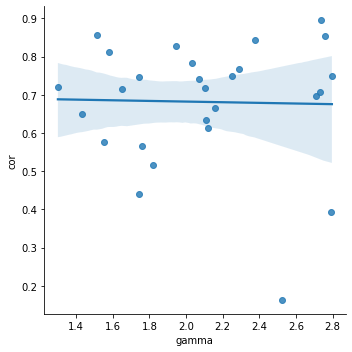

In [52]:
sns.lmplot(x='gamma', y='cor', data=df_comb)